## Code to Calculate Total Line Absorbed Flux

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import LineLocking_FinalVersion as LineLocking
from astropy.table import Table
from tqdm.notebook import tqdm
from multiprocessing import Pool
import os
from astropy import units as u
from astropy import constants as const
import pandas as pd
from scipy.integrate import trapezoid
from scipy.signal import medfilt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


### Set user paths to spectra and read in the trough catalog

In [18]:
species = 'CIV'
blue_line = 1548.20
red_line = 1550.77

# path to spectra
specdir = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/dr16Q/spectra/lite/'
# path to the trough file
trough_cat =  '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/'+species+'_trough_catalog_N'
# catalog containing the PCA information
balfilename = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/PCA_files/DR16Q_BAL_CIV.fits'
# eigenvectors
pcaeigenfile = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/PCA_files/PCA_Eigenvectors_Brodzeller.fits'
# mean quasar spectrum
meancontinuum = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/mean_fz_out_full.dat'

# Load the table from the FITS file
Quasar_table = Table.read("Data/DR16Q_v4.fits", hdu=1)
column_names = ['PLATE', 'FIBERID', 'MJD', 'BAL_PROB', 'Z_PCA']
# Keep only required columns and convert to pandas
Quasar_table = Quasar_table[column_names].to_pandas()

trough_table = Table.read(trough_cat, hdu=1)
trough_table = trough_table.to_pandas()

### Select desired troughs from the catalog to be used in the analysis

In [19]:
print (trough_table.shape)
trough_table = trough_table[trough_table['PCA_CHI2'] <5.] 
print (trough_table.shape)
trough_table = trough_table[trough_table['SN_MEDIAN_ALL'] > 2.]
print (trough_table.shape)
trough_table = trough_table[trough_table['SDSS_CHI2'] <10.]
print (trough_table.shape)
# trough_table = trough_table[trough_table['FMIN'] > 0.01]
# print (trough_table.shape)
# trough_table = trough_table[trough_table['FMIN'] < 0.99]
# print (trough_table.shape)
trough_table = trough_table[trough_table['BAL_PROB'] > 0.8]
print (trough_table.shape)

nonBAL_table = Quasar_table[Quasar_table['BAL_PROB'] == 0]

(159690, 21)
(157641, 21)
(138755, 21)
(137117, 21)
(116428, 21)


## Determine the file paths for each quasar spectra

In [4]:
# qso_names = []
# for i in range(len(trough_table)):
#     qso_names.append(LineLocking.determine_spec_fileName(trough_table.iloc[i], specdir))

# # Get the unique qsos
# unique_qso = np.unique(qso_names)
# avgNumTroughs = len(qso_names)/len(unique_qso)
# print(f"The average number of troughs per Quasar: {avgNumTroughs}")
# # This will store the index lists
# index_arrays = [] 
# # Loop through each unique string in the list
# for qso in tqdm(unique_qso):
#     # Create a list to store indices for this specific item
#     indices_for_qso = []
#     # Loop through the list and find where this item appears
#     for i, x in enumerate(qso_names):
#         if x == qso:
#             indices_for_qso.append(i)
    
#     # Add the result to the main list
#     index_arrays.append(indices_for_qso)
# np.save(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Full_Spectra_Stacks/index_array', np.array(index_arrays, dtype=object))

In [20]:
index_arrays = np.load(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Full_Spectra_Stacks/index_array.npy', allow_pickle=True)

In [22]:
num_quasars = len(index_arrays)

num_troughs = sum(len(i) for i in index_arrays)

avg_troughs_per_qso = np.mean([len(i) for i in index_arrays])

print(f"Number of quasars: {num_quasars}")
print(f"Number of troughs: {num_troughs}")
print(f"Average troughs per quasar: {avg_troughs_per_qso}")

Number of quasars: 73442
Number of troughs: 116428
Average troughs per quasar: 1.5853054110726832


## Check to see if the code works

Total Luminosity of Quasar: 5.3999736806165886e+45 erg/s
Trough 39437 has area: 2.10e-15 erg/s/cm^2, and Mdot:6.77e-02 Msun/yr


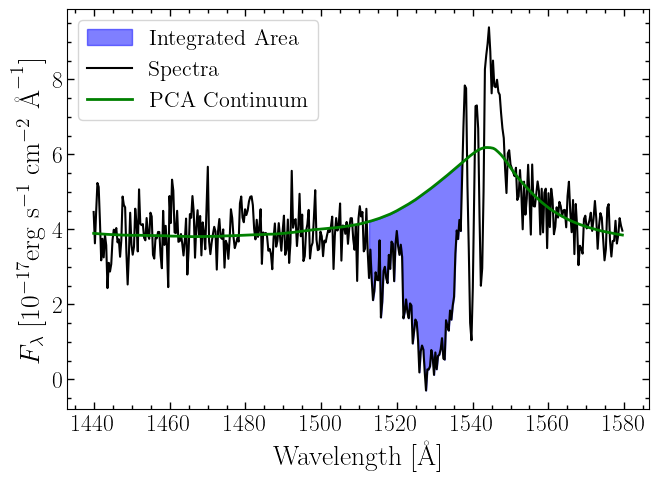

Total Area: 2.10e-15 erg/s/cm^2, made from 1 troughs.
Total Mdot: 6.77e-02 Msun/yr, made from 1 troughs.


In [7]:
total_area = LineLocking.get_area(index_arrays[121], trough_table, specdir, balfilename, pcaeigenfile, plot=True, verbose=True)

## Determine Contributions from other Lines

In [8]:
# stacking_spectra = LineLocking.Full_Spectrum_Stack(trough_table, spectrum_directory=specdir, Continuum_Type='Model')
# np.savetxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Full_Spectra_Stacks/Model.csv', np.array(stacking_spectra), delimiter=',')

### First Read in the stacked spectra

In [9]:
#### Stack the Real Spectra
stacking_spectra_data = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Full_Spectra_Stacks/Model.csv', delimiter=',')
stacked_spectra = np.nanmedian(np.vstack(stacking_spectra_data), axis=0)
stacked_spectra_error = np.nanstd(np.vstack(stacking_spectra_data), axis=0)/2
stacking_wavelengths = np.arange(900.2, 1599.8, 0.3)

### Now mask out the known absorption lines and apply a median smoothing algorithm

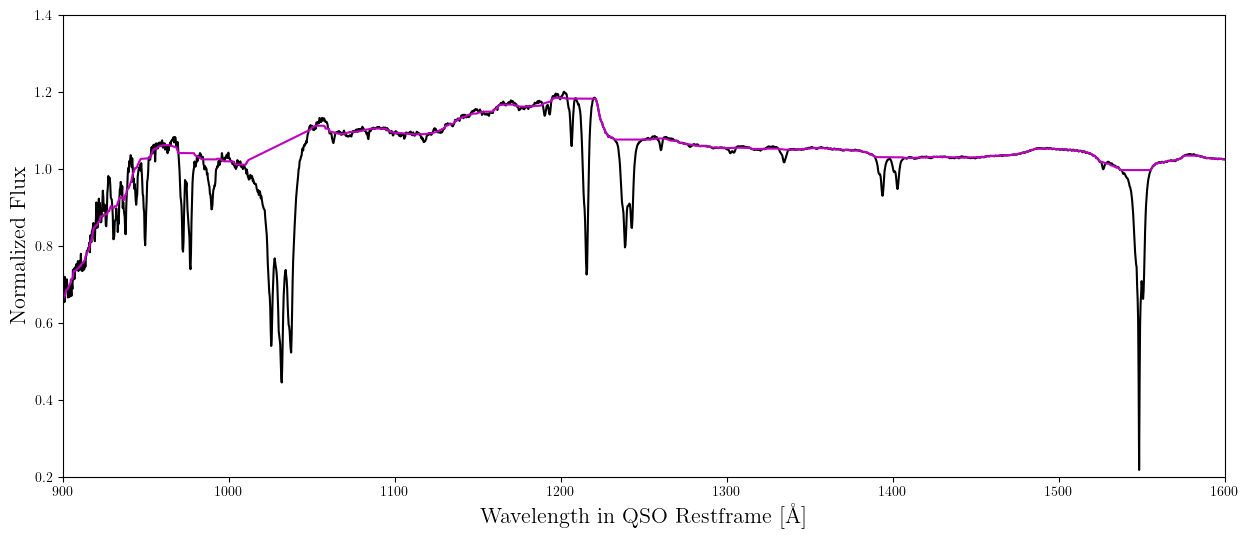

In [10]:
stacking_wavelengths = np.array(stacking_wavelengths)
stacking_spectra = np.array(stacked_spectra)

mask = np.ones_like(stacking_spectra, dtype=bool)
# Mask out several wavelength regions
line_regions = [
    (1543, 1553),  # CIV
    (1390, 1405),  # SiIV
    (1234, 1245),  # NV
    (1203, 1220),  # HI
    (1012, 1048),  # OVI
    (986, 992),  # NIII
    (969.5, 979),  # CIII
    (947.5, 952)
]
for start, end in line_regions:
    mask &= ~((stacking_wavelengths >= start) & (stacking_wavelengths <= end))
# Apply mask
masked_flux = stacked_spectra[mask]
masked_wavelength = stacking_wavelengths[mask]

size=51
smoothed = medfilt(masked_flux, kernel_size=size)
smoothed = np.interp(stacking_wavelengths, masked_wavelength, smoothed)


plt.figure(figsize=(15,6))
plt.plot(stacking_wavelengths, stacked_spectra, 'k')
plt.plot(stacking_wavelengths, smoothed, 'm')
#plt.plot(masked_wavelength, masked_flux, 'red')
plt.ylim(0.2, 1.4)
plt.xlim(900, 1600)
plt.xlabel(r'Wavelength in QSO Restframe [$\mathrm{\AA}$]', fontsize=16)
plt.ylabel(r"Normalized Flux", fontsize=16)
plt.show()

### Now take the residual between the stack and the smooth. Integrate to find total area and CIV area

-17.644225642799867
-2.6157628386776293
0.14825036199562838


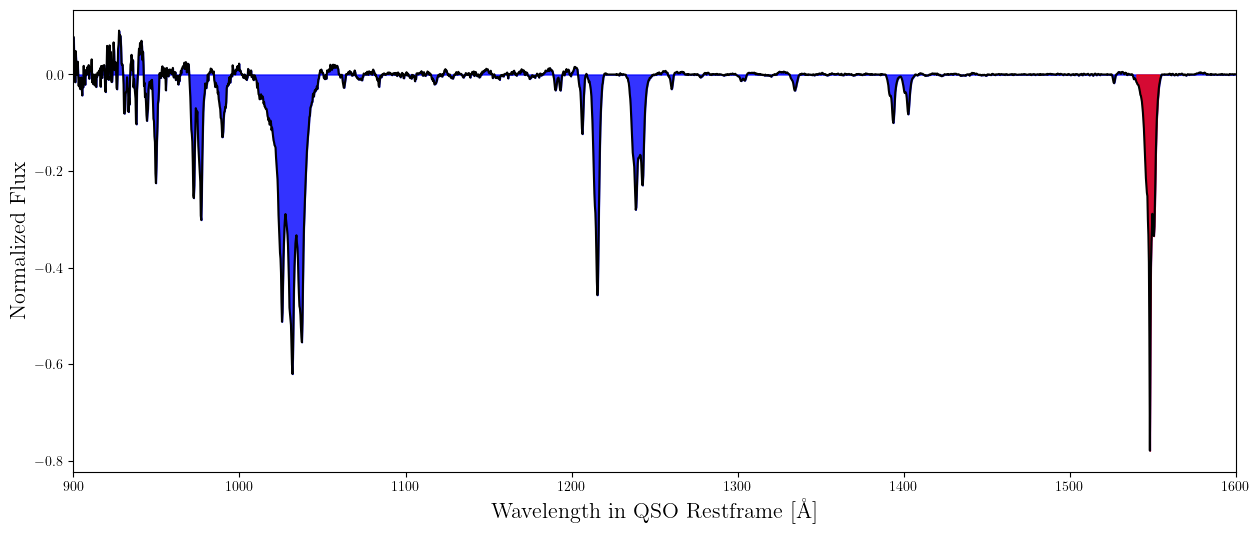

In [11]:
# Find total Area
area = trapezoid(stacked_spectra-smoothed, stacking_wavelengths)
print(area)
# Find CIV area
CIV_minIDX = np.argmin(np.abs(stacking_wavelengths-1540))
CIV_maxIDX = np.argmin(np.abs(stacking_wavelengths-1554))
CIV_area=total_emission = trapezoid(stacked_spectra[CIV_minIDX:CIV_maxIDX]-smoothed[CIV_minIDX:CIV_maxIDX], stacking_wavelengths[CIV_minIDX:CIV_maxIDX])
print(CIV_area)
print(CIV_area/area)

plt.figure(figsize=(15,6))
plt.plot(stacking_wavelengths, stacked_spectra-smoothed, 'k')
plt.fill_between(stacking_wavelengths, stacked_spectra-smoothed, 0, color='blue', alpha=0.8, label='Integrated Area')
plt.fill_between(stacking_wavelengths[CIV_minIDX:CIV_maxIDX], stacked_spectra[CIV_minIDX:CIV_maxIDX]-smoothed[CIV_minIDX:CIV_maxIDX], 0, color='red', alpha=0.8, label='Integrated Area')
plt.xlim(900, 1600)
plt.xlabel(r'Wavelength in QSO Restframe [$\mathrm{\AA}$]', fontsize=16)
plt.ylabel(r"Normalized Flux", fontsize=16)
plt.show()

## Now multiply by the continuum to correct for continuum effects

In [12]:
# ── Pre-compute the shared wavelength grid once at module level ──────────────
# Avoids recreating this ~22,000-element array on every function call.
REBIN_WAVELENGTHS = np.arange(600.2, 2799.8, 0.1)
_N_BINS = len(REBIN_WAVELENGTHS)

# Pre-compute the normalization mask once (it never changes).
_NORM_MASK = (REBIN_WAVELENGTHS > 2000) & (REBIN_WAVELENGTHS < 2200)

# BAL transition rest wavelengths (CIV, NV, HI, OVI, SiIV)
_BAL_LINES = np.array([1548.20, 1238.821, 1215.670, 1031.926, 1393.755])


def get_spectra_from_table(trough_table, BAL_Table=False):
    """
    Build and return the mean stacked spectrum.

    Key memory optimisations vs. the original:
    - Incremental running mean (sum + count) instead of accumulating every
      spectrum in a list and then np.vstack-ing — memory stays O(n_bins)
      instead of O(N_spectra × n_bins).
    - float32 for per-spectrum flux arrays (halves per-spectrum footprint).
    - np.searchsorted instead of np.argmin(np.abs(...)) for trough bounds
      — faster and creates no temporary array.
    - No trough_table.copy() — groups by a temporary Series.
    - Large intermediates deleted explicitly to let the GC reclaim them
      promptly within the loop.

    Returns
    -------
    mean_spectrum : ndarray, shape (n_bins,)
        Nan-mean of all accepted spectra. NaN where no spectrum contributed.
    count_array : ndarray of int32, shape (n_bins,)
        Number of spectra that contributed to each wavelength bin.
        Equivalent to np.any(np.isfinite(stacked), axis=0) from the
        original code, but computed without ever building the 2-D stack.
    rejection_counter : int
    """
    rejection_counter = 0
    c = const.c.value / 1000  # km/s

    # Incremental accumulators — the whole trick.
    # Instead of list → vstack → nanmean we keep just two arrays.
    running_sum   = np.zeros(_N_BINS, dtype=np.float64)
    running_count = np.zeros(_N_BINS, dtype=np.int32)

    # Group by SPECNAME without touching (or copying) the original table.
    spec_names = trough_table.apply(
        lambda row: LineLocking.determine_spec_fileName(row, specdir), axis=1
    )
    grouped = trough_table.groupby(spec_names)

    for specname, group in tqdm(grouped):
        # ── Load spectrum ────────────────────────────────────────────────
        try:
            current_spec_data = LineLocking.read_spec(specname)
        except Exception:
            continue

        z = group.iloc[0]["Z_PCA"]
        x = current_spec_data["WAVE_OBS"].values / (1.0 + z)
        y = current_spec_data["FLUX"].values

        # ── Sky mask (boolean, not float) ────────────────────────────────
        sky_interp = np.interp(
            REBIN_WAVELENGTHS, x,
            LineLocking.find_sky_line(current_spec_data["WAVE_OBS"])
        )
        sky_mask = sky_interp > 0.01
        del sky_interp, current_spec_data   # free promptly

        # ── Interpolate flux — float32 halves memory vs float64 ──────────
        in_range = (REBIN_WAVELENGTHS >= x.min()) & (REBIN_WAVELENGTHS <= x.max())
        rebin_flux = np.full(_N_BINS, np.nan, dtype=np.float32)
        rebin_flux[in_range] = np.interp(REBIN_WAVELENGTHS[in_range], x, y)
        del x, y, in_range

        # ── Normalise ─────────────────────────────────────────────────────
        valid_norm = rebin_flux[_NORM_MASK]
        valid_norm = valid_norm[np.isfinite(valid_norm)]
        if len(valid_norm) <= 30:
            rejection_counter += 1
            del rebin_flux, valid_norm
            continue

        median_flux = float(np.median(valid_norm))
        del valid_norm
        if median_flux == 0.0:
            rejection_counter += 1
            del rebin_flux
            continue

        corrected_flux = rebin_flux / median_flux   # still float32
        del rebin_flux

        # ── BAL trough masking ────────────────────────────────────────────
        if BAL_Table:
            for _, row in group.iterrows():
                z_min  = row["Z_MIN"]
                vmin   = row["VMIN"]
                vmax   = row["VMAX"]
                posmin = row["POSMIN"]
                z_ratio = (1.0 + z_min) / (1.0 + z)   # compute once per row

                for line in _BAL_LINES:
                    # Combine the two-step rest-frame → quasar-frame conversion
                    wl_lower = line * (1.0 - (vmax - posmin) / c) * z_ratio
                    wl_upper = line * (1.0 + (posmin - vmin)  / c) * z_ratio

                    # searchsorted: no temporary array, faster than argmin(abs(...))
                    # 'left'  → first index where REBIN_WAVELENGTHS[i] >= wl_lower
                    # 'right' → one past the last index where array[i] <= wl_upper
                    lo = np.searchsorted(REBIN_WAVELENGTHS, wl_lower, side="left")
                    hi = np.searchsorted(REBIN_WAVELENGTHS, wl_upper, side="right") - 1
                    if hi > lo:
                        corrected_flux[lo:hi] = np.nan

        # ── Apply sky mask and check validity ─────────────────────────────
        corrected_flux[sky_mask] = np.nan
        finite = np.isfinite(corrected_flux)
        if not finite.any():
            rejection_counter += 1
            del corrected_flux, finite
            continue

        # ── Accumulate into running mean ──────────────────────────────────
        # This is the key change: O(n_bins) memory instead of O(N × n_bins).
        running_sum[finite]   += corrected_flux[finite].astype(np.float64)
        running_count[finite] += 1
        del corrected_flux, finite

    # ── Compute mean from accumulators ────────────────────────────────────
    with np.errstate(invalid="ignore"):
        mean_spectrum = np.where(
            running_count > 0,
            running_sum / running_count,
            np.nan,
        )

    return mean_spectrum, running_count, rejection_counter


nonBAL_mean, nonBAL_count, nonBALreject = get_spectra_from_table(nonBAL_table)
nonBAL_mask = nonBAL_count > 0

nonBAL_Stack          = nonBAL_mean[nonBAL_mask]
continuum_wls_filtered = REBIN_WAVELENGTHS[nonBAL_mask]

  0%|          | 0/313735 [00:00<?, ?it/s]

In [13]:
#### Need super sampling to reduce aliasing effects from sliding two functions on top of each other with course grain resolution (needed for next cell)
#### And to fill in the holes in the continuum imposed by the nonBAL_mask
superSample_wls =  np.arange(600.2, 2799.8, 0.1)
continuum = np.interp(superSample_wls, continuum_wls_filtered, nonBAL_Stack)

<>:114: SyntaxWarning: invalid escape sequence '\%'
<>:114: SyntaxWarning: invalid escape sequence '\%'
/var/folders/b9/j3sh3wq91237z_qzrkn1vmv80000gn/T/ipykernel_75303/2176896523.py:114: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel('Ratio of CIV Absorption \n to Total Absorption [\%]', fontsize=labelsize-5)


Total Area: 67.42590300567382
CIV Area: 11.078727653846043
Fraction: 0.16430966675987685


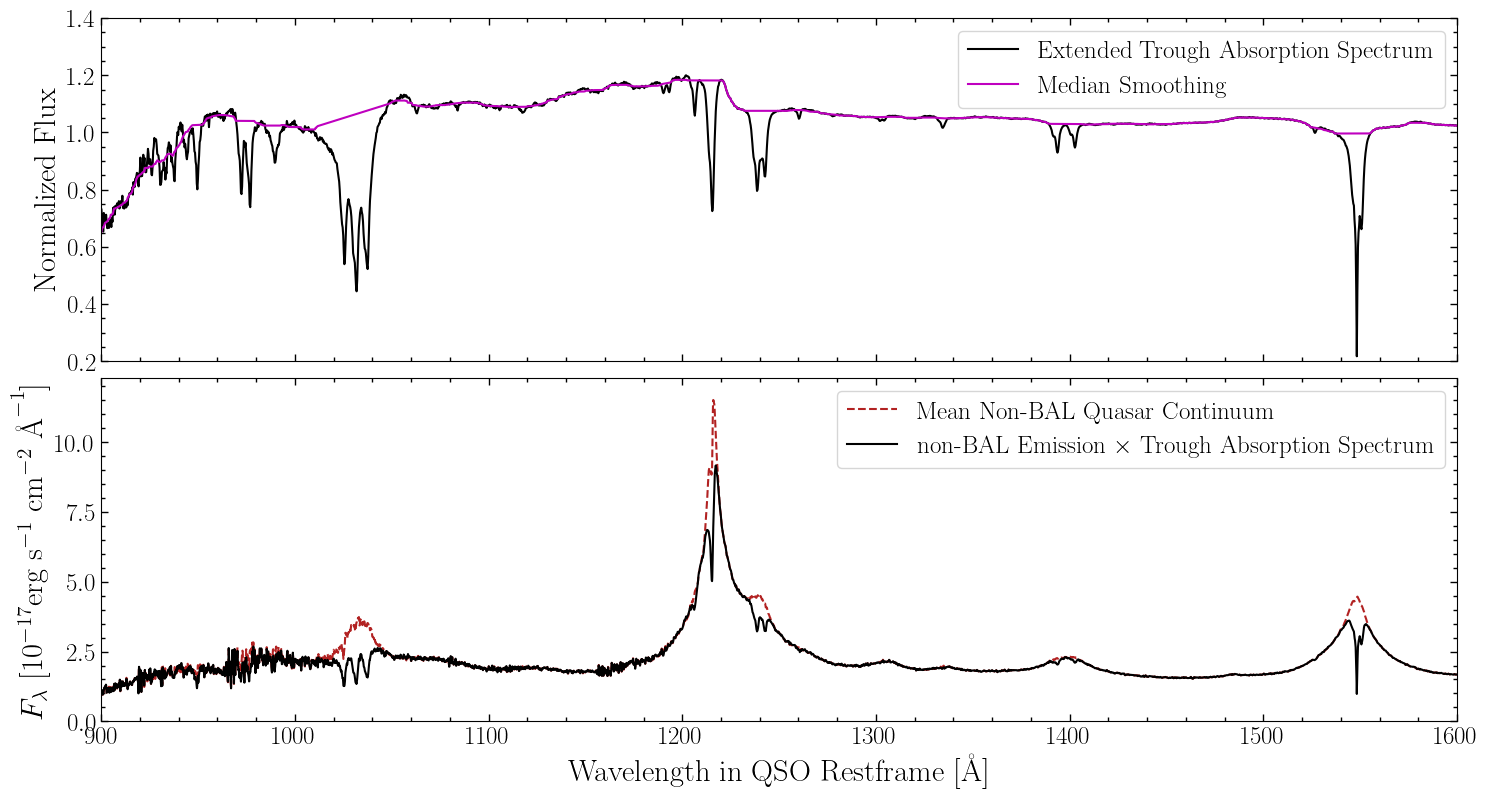

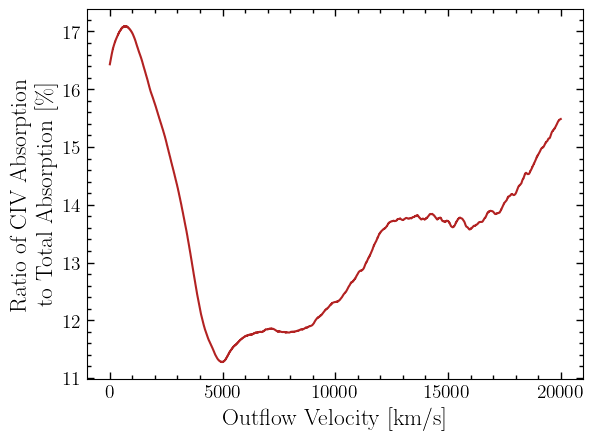

In [16]:
def relativistic_wavelength_shift(lambda_0, velocity_kms):
    c = const.c.value / 1000  # km/s  # Speed of light in km/s
    beta = velocity_kms / c
    
    # Prevent invalid values (|v| >= c)
    if abs(beta) >= 1:
        raise ValueError("Velocity must be less than the speed of light.")
    
    doppler_factor = ((1 + beta) / (1 - beta))**0.5
    lambda_obs = lambda_0 * doppler_factor
    delta_lambda = lambda_obs - lambda_0
    
    return delta_lambda


def Calculate_Relative_Absorption(velocities):
    #### Clean and smooth the average absorption profile
    absorption_profile = stacked_spectra-smoothed+1

    relative = []
    for v in velocities:
        # Now shift the absorption profile by 1000 km/s
        shift = relativistic_wavelength_shift(1550, v)
        shifted_absorption_profile = np.interp(superSample_wls+shift, stacking_wavelengths, absorption_profile, left=np.nan,right=np.nan)

        # Now multiply shifted absorption profile by continuum
        result = shifted_absorption_profile*continuum

        # Now compute area difference
        diff = continuum - result
        valid = np.isfinite(diff)
        area = trapezoid(diff[valid], superSample_wls[valid])
        
        civ_mask = ((superSample_wls >= 1540 - shift) & (superSample_wls <= 1554 - shift))
        valid_civ = valid & civ_mask
        CIV_area = trapezoid(diff[valid_civ], superSample_wls[valid_civ])

        relative.append(CIV_area/area)
    return relative



#### Clean and smooth the average absorption profile
absorption_profile = stacked_spectra-smoothed+1

# Now shift the absorption profile by 1000 km/s
shift = relativistic_wavelength_shift(1550, 0)
shifted_absorption_profile = np.interp(superSample_wls+shift, stacking_wavelengths, absorption_profile, left=np.nan, right=np.nan)

# Now multiply shifted absorption profile by continuum
result = shifted_absorption_profile*continuum

# Now compute area difference
diff = continuum - result
valid = np.isfinite(diff)
area = trapezoid(diff[valid], superSample_wls[valid])
print(f"Total Area: {area}")

civ_mask = ((superSample_wls >= 1540 - shift) & (superSample_wls <= 1554 - shift))
valid_civ = valid & civ_mask
CIV_area = trapezoid(diff[valid_civ], superSample_wls[valid_civ])
print(f"CIV Area: {CIV_area}")
print(f"Fraction: {CIV_area/area}")




fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
labelsize=22
ticksize=16
# Top plot
ax1.plot(stacking_wavelengths, stacked_spectra, 'k', label='Extended Trough Absorption Spectrum')
ax1.plot(stacking_wavelengths, smoothed, 'm', label='Median Smoothing')
ax1.set_ylim(0.2, 1.4)
ax1.set_xlim(900, 1600)
ax1.set_ylabel(r"Normalized Flux", fontsize=labelsize)
ax1.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax1.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax1.legend(fontsize=labelsize-4)

# Bottom plot
ax2.plot(superSample_wls, continuum, color='firebrick', linestyle='--', label='Mean Non-BAL Quasar Continuum')
ax2.plot(superSample_wls, result, label=r'non-BAL Emission $\times$ Trough Absorption Spectrum', color='k')
ax2.set_xlabel(r'Wavelength in QSO Restframe [$\mathrm{\AA}$]', fontsize=labelsize)
ax2.set_ylabel(r" $F_\lambda$ [$10^{-17}$erg s$^{-1}$ cm$^{-2}$ $\mathrm{\AA}^{-1}$]", fontsize=labelsize)
ax2.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax2.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax2.set_ylim(0, 12.3)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.legend(fontsize=labelsize-4)
plt.tight_layout()
plt.savefig("Results/Figures/Extended_Stack.png", bbox_inches="tight", dpi=300)
plt.show()

# Now show change
vs = np.arange(0, 20000, 0.1)
relativeVals = Calculate_Relative_Absorption(vs)
np.savez('/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/CIV_relative_absorption_data.npz', velocities=vs, relative_vals=relativeVals)

plt.plot(vs, np.array(relativeVals)*100, color='firebrick')
plt.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize-2)
plt.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
plt.xlabel('Outflow Velocity [km/s]', fontsize=labelsize-5)
plt.ylabel('Ratio of CIV Absorption \n to Total Absorption [\%]', fontsize=labelsize-5)
plt.minorticks_on()
plt.savefig("Results/Figures/CIV_Absorption_Ratios.png", bbox_inches="tight", dpi=300)
plt.show()

### Rerun calculation accounting for other lines

In [ ]:
relative_absorption_filename = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/CIV_relative_absorption_data.npz'

if __name__ == "__main__":
    arg_list = [(index_arrays[i], trough_table, specdir, balfilename, pcaeigenfile, relative_absorption_filename) for i in range(len(index_arrays))]

    with Pool(processes=int(os.cpu_count() * 0.75)) as pool:
        results = list(tqdm(pool.imap_unordered(LineLocking.wrapper, arg_list), total=len(arg_list)))

results_df = pd.DataFrame(results)
#results_df.to_csv('results_new.csv')

  0%|          | 0/73442 [00:00<?, ?it/s]

## Use Clustering to find 2 populations

Removed 2 Quasars due to negative calculated Mdot


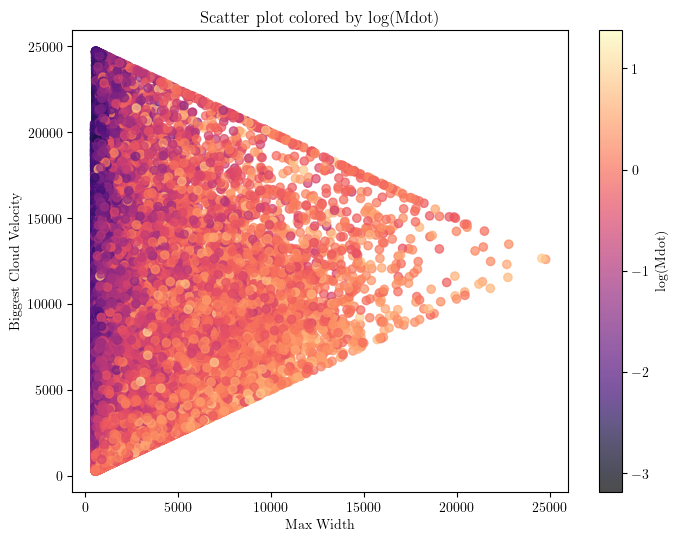

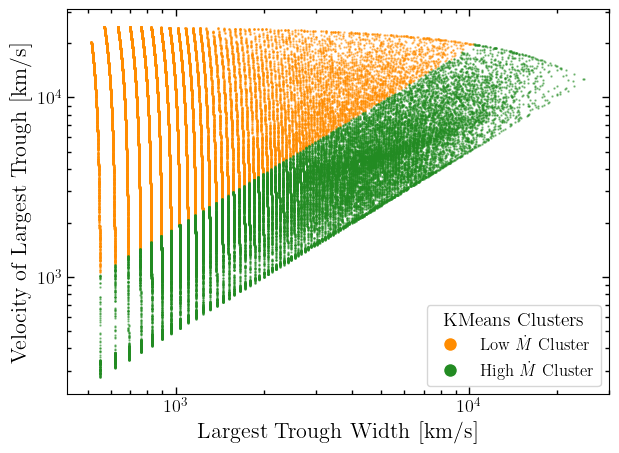

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing
from sklearn.cluster import KMeans

# Filter out non-positive Mdot values to avoid -inf or NaN
original_num = len(results_df)
results_df = results_df[results_df['Mdot'] > 0]
print(f"Removed {original_num-len(results_df)} Quasars due to negative calculated Mdot")
# Add a log-transformed column for hue
results_df['log_Mdot'] = np.log10(results_df['Mdot'])

ticksize=15

# Plot 1: colored by log_Mdot
plt.figure(figsize=(8, 6))
scatter1 = plt.scatter(
    results_df['Max Width'], 
    results_df['Biggest Cloud Velocity'], 
    c=results_df['log_Mdot'], 
    cmap='magma',
    alpha=0.7
)
plt.colorbar(scatter1, label='log(Mdot)')
plt.xlabel('Max Width')
plt.ylabel('Biggest Cloud Velocity')
plt.title('Scatter plot colored by log(Mdot)')
plt.show()

# Use full dataset for clustering (no splitting)
X_train = results_df[['Max Width', 'Biggest Cloud Velocity']]

# Normalize
X_train_norm = preprocessing.normalize(X_train)

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans.fit(X_train_norm)

# Add cluster labels to results_df
results_df['cluster'] = kmeans.labels_

# Plot 2: colored by cluster labels
plt.figure(figsize=(7, 5))

# Plot each cluster separately to assign labels
for cluster_id, color in zip([0, 1], ['darkorange', 'forestgreen']):
    cluster_data = results_df[results_df['cluster'] == cluster_id]
    plt.scatter(
        cluster_data['Max Width'],
        cluster_data['Biggest Cloud Velocity'],
        color=color,
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=0.5
    )

# Plot the line
plt.xlabel('Largest Trough Width [km/s]', fontsize=16)
plt.ylabel('Velocity of Largest Trough [km/s]', fontsize=16)
plt.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize-2)
plt.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
plt.minorticks_on()

# Add the legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=r'Low $\dot{M}$ Cluster',
           markerfacecolor='darkorange', markersize=10),
    Line2D([0], [0], marker='o', color='w', label=r'High $\dot{M}$ Cluster',
           markerfacecolor='forestgreen', markersize=10)]
plt.legend(
    handles=legend_elements,
    title='KMeans Clusters',
    title_fontsize=14,
    fontsize=12
)
plt.yscale('log')
plt.xscale('log')
plt.savefig("Results/Figures/Kcluster_test.png", bbox_inches="tight", dpi=300)
plt.show()


# Split into two DataFrames based on cluster label 0 and 1
cluster_0_df = results_df[results_df['cluster'] == 0]
cluster_1_df = results_df[results_df['cluster'] == 1]


In [15]:
cluster_0_df.to_parquet("/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cluster0_data.parquet", index=False)
cluster_1_df.to_parquet("/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cluster1_data.parquet", index=False)

# Use Advanced Clustering Data

In [19]:
clustered_data = pd.read_csv("./results_clustered.csv")
results_df = clustered_data
cluster_0_df = clustered_data[clustered_data['cluster'] == 0]
cluster_1_df = clustered_data[clustered_data['cluster'] == 1]
cluster_2_df = clustered_data[clustered_data['cluster'] == -1]

## Plot Results

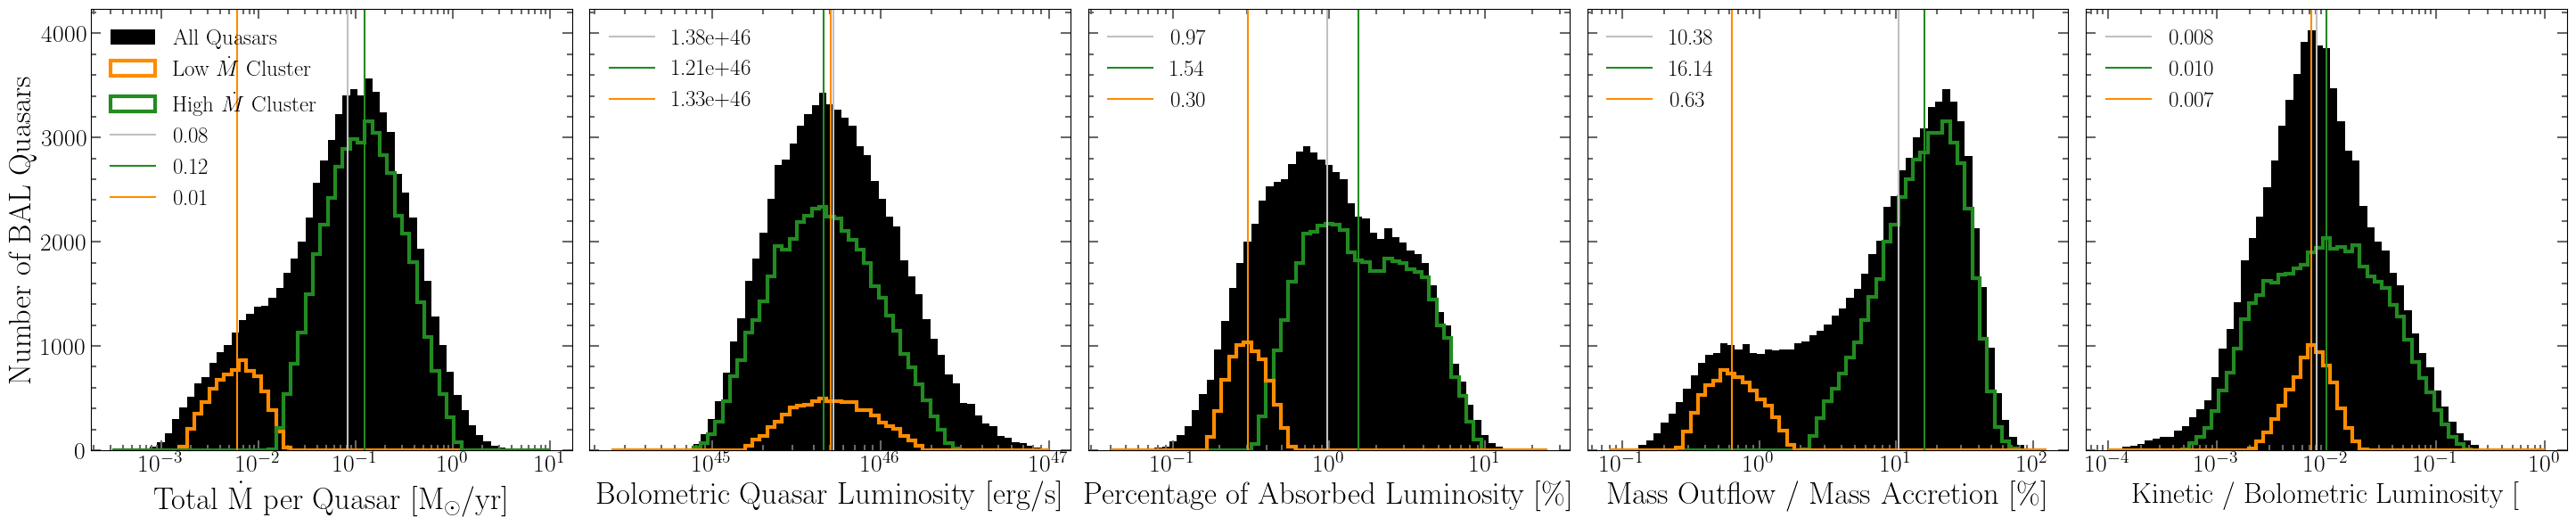

In [20]:
cover_factor = 0.38 # The fraction of the quasar’s sky (as seen from the central engine) that is covered by absorbing material.

fig, axes = plt.subplots(1, 5, figsize=(29, 6), sharey=True)  # 1 row, 3 columns
font=25
ticksize=22

# === Plot 1: Mass Outflow Rate ===
bins = np.logspace(-3.5, 1, 60)
axes[0].hist(results_df['Mdot']*cover_factor, bins=bins, density=False, alpha=1., color='k', label='All Quasars')
axes[0].hist(cluster_1_df['Mdot']*cover_factor, bins=bins, histtype='step', linewidth=3., density=False, alpha=1., color='darkorange', label=r'Low $\dot{M}$ Cluster')
axes[0].hist(cluster_0_df['Mdot']*cover_factor, bins=bins, histtype='step', linewidth=3., density=False, alpha=1., color='forestgreen', label=r'High $\dot{M}$ Cluster')
axes[0].set_xlabel(r'Total $\dot{\mathrm{M}}$ per Quasar [M$_{\odot}$/yr]', fontsize=font)
axes[0].set_ylabel(r'Number of BAL Quasars', fontsize=font)
axes[0].set_xscale('log')
axes[0].axvline(x=np.median(results_df['Mdot']*cover_factor), color='silver', label=f"{np.median(results_df['Mdot']*cover_factor):.2f}")
axes[0].axvline(x=np.median(cluster_0_df['Mdot']*cover_factor), color='forestgreen', label=f"{np.median(cluster_0_df['Mdot']*cover_factor):.2f}")
axes[0].axvline(x=np.median(cluster_1_df['Mdot']*cover_factor), color='darkorange', label=f"{np.median(cluster_1_df['Mdot']*cover_factor):.2f}")
axes[0].legend(fontsize=font-7, loc='upper left', frameon=False)
axes[0].tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[0].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
axes[0].minorticks_on()

# === Plot 2: Bolometric Luminosity ===
bins = np.logspace(44.4, 47, 60)
axes[1].hist(results_df['L_bol'], bins=bins, density=False, color='k')
axes[1].hist(cluster_0_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
axes[1].hist(cluster_1_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
axes[1].set_xlabel("Bolometric Quasar Luminosity [erg/s]", fontsize=font)
axes[1].set_xscale('log')
axes[1].axvline(x=np.median(results_df['L_bol']), color='silver', label=f"{np.median(results_df['L_bol']/cover_factor):.2e}")
axes[1].axvline(x=np.median(cluster_0_df['L_bol']), color='forestgreen', label=f"{np.median(cluster_0_df['L_bol']/cover_factor):.2e}")
axes[1].axvline(x=np.median(cluster_1_df['L_bol']), color='darkorange', label=f"{np.median(cluster_1_df['L_bol']/cover_factor):.2e}")
axes[1].legend(fontsize=font-7, loc='upper left', frameon=False)
axes[1].tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[1].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
axes[1].minorticks_on()

# === Plot 3: Absorption Fraction ===
bins = np.logspace(-1.4, 1.4, 60)
axes[2].hist(100*results_df['L_absorbed']*cover_factor/results_df['L_bol'], bins=bins, density=False, color='k')
axes[2].hist(100*cluster_0_df['L_absorbed']*cover_factor/cluster_0_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
axes[2].hist(100*cluster_1_df['L_absorbed']*cover_factor/cluster_1_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
axes[2].set_xlabel(r"Percentage of Absorbed Luminosity [\%]", fontsize=font)
axes[2].set_xscale('log')
axes[2].axvline(x=np.median(100 * results_df['L_absorbed']*cover_factor / results_df['L_bol']), color='silver', label=f"{np.median(100 * results_df['L_absorbed']*cover_factor / results_df['L_bol']):.2f}")
axes[2].axvline(x=np.median(100 * cluster_0_df['L_absorbed']*cover_factor / cluster_0_df['L_bol']), color='forestgreen', label=f"{np.median(100 * cluster_0_df['L_absorbed']*cover_factor / cluster_0_df['L_bol']):.2f}")
axes[2].axvline(x=np.median(100 * cluster_1_df['L_absorbed']*cover_factor / cluster_1_df['L_bol']), color='darkorange', label=f"{np.median(100 * cluster_1_df['L_absorbed']*cover_factor / cluster_1_df['L_bol']):.2f}")
axes[2].legend(fontsize=font-7, loc='upper left', frameon=False)
axes[2].tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[2].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
axes[2].minorticks_on()

# === Plot 4: Mass ratios ===
bins = np.logspace(-1.1, 2.1, 60)
axes[3].hist(100*results_df['Mass_Ratio']*cover_factor, bins=bins, density=False, color='k')
axes[3].hist(100*cluster_0_df['Mass_Ratio']*cover_factor, bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
axes[3].hist(100*cluster_1_df['Mass_Ratio']*cover_factor, bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
axes[3].set_xlabel(r"Mass Outflow / Mass Accretion [\%]", fontsize=font)
axes[3].set_xscale('log')
axes[3].axvline(x=np.median(100*results_df['Mass_Ratio']*cover_factor), color='silver', label=f"{np.median(100*results_df['Mass_Ratio']*cover_factor):.2f}")
axes[3].axvline(x=np.median(100*cluster_0_df['Mass_Ratio']*cover_factor), color='forestgreen', label=f"{np.median(100*cluster_0_df['Mass_Ratio']*cover_factor):.2f}")
axes[3].axvline(x=np.median(100*cluster_1_df['Mass_Ratio']*cover_factor), color='darkorange', label=f"{np.median(100*cluster_1_df['Mass_Ratio']*cover_factor):.2f}")
axes[3].legend(fontsize=font-7, loc='upper left', frameon=False)
axes[3].tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[3].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
axes[3].minorticks_on()

bins = np.logspace(-4, 0, 60)
axes[4].hist(100*results_df['L_kin']*cover_factor/results_df['L_bol'], bins=bins, density=False, color='k')
axes[4].hist(100*cluster_0_df['L_kin']*cover_factor/cluster_0_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
axes[4].hist(100*cluster_1_df['L_kin']*cover_factor/cluster_1_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
axes[4].axvline(x=np.median(100*results_df['L_kin']*cover_factor/results_df['L_bol']), color='silver', label=f"{np.median(100*results_df['L_kin']*cover_factor/results_df['L_bol']):.3f}")
axes[4].axvline(x=np.median(100*cluster_0_df['L_kin']*cover_factor/cluster_0_df['L_bol']), color='forestgreen', label=f"{np.median(100*cluster_0_df['L_kin']*cover_factor/cluster_0_df['L_bol']):.3f}")
axes[4].axvline(x=np.median(100*cluster_1_df['L_kin']*cover_factor/cluster_1_df['L_bol']), color='darkorange', label=f"{np.median(100*cluster_1_df['L_kin']*cover_factor/cluster_1_df['L_bol']):.3f}")
axes[4].set_xlabel("Kinetic / Bolometric Luminosity [%]", fontsize=font-2)
axes[4].set_xscale('log')
axes[4].legend(fontsize=font-7, loc='upper left', frameon=False)
axes[4].tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[4].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
axes[4].minorticks_on()

#fig.suptitle(r"Only use BAL_PROB>0.9", fontsize=font+4)
plt.tight_layout()
plt.savefig("Results/Figures/Mass_Outflow_Histograms.png", bbox_inches="tight", dpi=300)
plt.show()


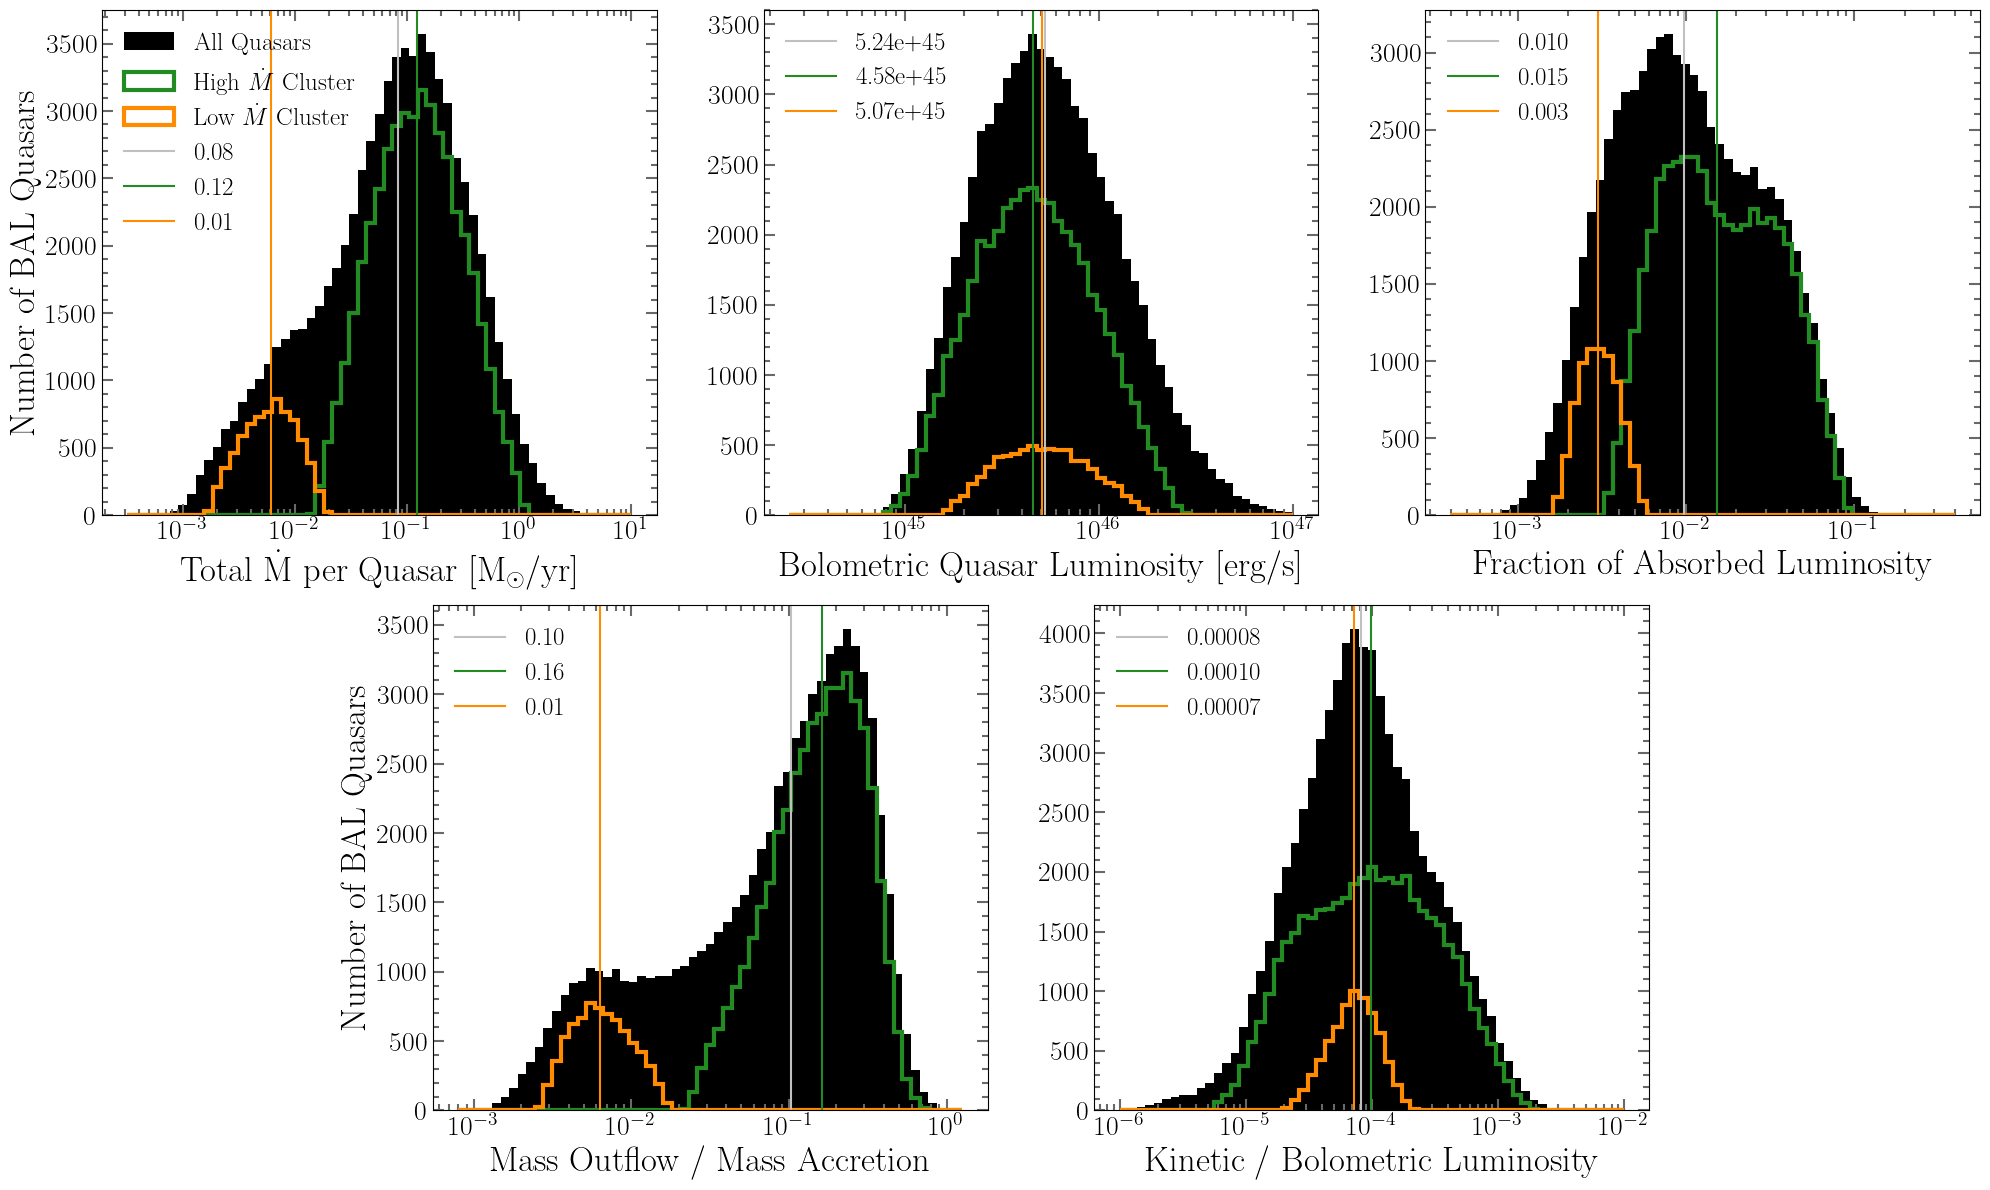

In [21]:
cover_factor = 0.38 # The fraction of the quasar’s sky (as seen from the central engine) that is covered by absorbing material.
font=25
ticksize=22

fig = plt.figure(figsize=(20, 12))
ax1 = plt.subplot2grid(shape=(2,6), loc=(0,0), colspan=2)
ax2 = plt.subplot2grid((2,6), (0,2), colspan=2)
ax3 = plt.subplot2grid((2,6), (0,4), colspan=2)
ax4 = plt.subplot2grid((2,6), (1,1), colspan=2)
ax5 = plt.subplot2grid((2,6), (1,3), colspan=2)


# === Plot 1: Mass Outflow Rate ===
bins = np.logspace(-3.5, 1, 60)
ax1.hist(results_df['Mdot']*cover_factor, bins=bins, density=False, alpha=1., color='k', label='All Quasars')
ax1.hist(cluster_0_df['Mdot']*cover_factor, bins=bins, histtype='step', linewidth=3., density=False, alpha=1., color='forestgreen', label=r'High $\dot{M}$ Cluster')
ax1.hist(cluster_1_df['Mdot']*cover_factor, bins=bins, histtype='step', linewidth=3., density=False, alpha=1., color='darkorange', label=r'Low $\dot{M}$ Cluster')
ax1.set_xlabel(r'Total $\dot{\mathrm{M}}$ per Quasar [M$_{\odot}$/yr]', fontsize=font)
ax1.set_ylabel(r'Number of BAL Quasars', fontsize=font)
ax1.set_xscale('log')
ax1.axvline(x=np.median(results_df['Mdot']*cover_factor), color='silver', label=f"{np.median(results_df['Mdot']*cover_factor):.2f}")
ax1.axvline(x=np.median(cluster_0_df['Mdot']*cover_factor), color='forestgreen', label=f"{np.median(cluster_0_df['Mdot']*cover_factor):.2f}")
ax1.axvline(x=np.median(cluster_1_df['Mdot']*cover_factor), color='darkorange', label=f"{np.median(cluster_1_df['Mdot']*cover_factor):.2f}")
ax1.legend(fontsize=font-7, loc='upper left', frameon=False)
ax1.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
ax1.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
ax1.minorticks_on()

# === Plot 2: Bolometric Luminosity ===
bins = np.logspace(44.4, 47, 60)
ax2.hist(results_df['L_bol'], bins=bins, density=False, color='k')
ax2.hist(cluster_0_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
ax2.hist(cluster_1_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
ax2.set_xlabel("Bolometric Quasar Luminosity [erg/s]", fontsize=font)
ax2.set_xscale('log')
ax2.axvline(x=np.median(results_df['L_bol']), color='silver', label=f"{np.median(results_df['L_bol']):.2e}")
ax2.axvline(x=np.median(cluster_0_df['L_bol']), color='forestgreen', label=f"{np.median(cluster_0_df['L_bol']):.2e}")
ax2.axvline(x=np.median(cluster_1_df['L_bol']), color='darkorange', label=f"{np.median(cluster_1_df['L_bol']):.2e}")
ax2.legend(fontsize=font-7, loc='upper left', frameon=False)
ax2.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
ax2.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
ax2.minorticks_on()

# === Plot 3: Absorption Fraction ===
bins = np.logspace(-3.4, -0.4, 60)
ax3.hist(results_df['L_absorbed']*cover_factor/results_df['L_bol'], bins=bins, density=False, color='k')
ax3.hist(cluster_0_df['L_absorbed']*cover_factor/cluster_0_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
ax3.hist(cluster_1_df['L_absorbed']*cover_factor/cluster_1_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
ax3.set_xlabel(r"Fraction of Absorbed Luminosity", fontsize=font)
ax3.set_xscale('log')
ax3.axvline(x=np.median(results_df['L_absorbed']*cover_factor / results_df['L_bol']), color='silver', label=f"{np.median(results_df['L_absorbed']*cover_factor / results_df['L_bol']):.3f}")
ax3.axvline(x=np.median(cluster_0_df['L_absorbed']*cover_factor / cluster_0_df['L_bol']), color='forestgreen', label=f"{np.median(cluster_0_df['L_absorbed']*cover_factor / cluster_0_df['L_bol']):.3f}")
ax3.axvline(x=np.median(cluster_1_df['L_absorbed']*cover_factor / cluster_1_df['L_bol']), color='darkorange', label=f"{np.median(cluster_1_df['L_absorbed']*cover_factor / cluster_1_df['L_bol']):.3f}")
ax3.legend(fontsize=font-7, loc='upper left', frameon=False)
ax3.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
ax3.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
ax3.minorticks_on()

# === Plot 4: Mass ratios ===
bins = np.logspace(-3.1, 0.1, 60)
ax4.hist(results_df['Mass_Ratio']*cover_factor, bins=bins, density=False, color='k')
ax4.hist(cluster_0_df['Mass_Ratio']*cover_factor, bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
ax4.hist(cluster_1_df['Mass_Ratio']*cover_factor, bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
ax4.set_xlabel(r"Mass Outflow / Mass Accretion", fontsize=font)
ax4.set_xscale('log')
ax4.set_ylabel(r'Number of BAL Quasars', fontsize=font)
ax4.axvline(x=np.median(results_df['Mass_Ratio']*cover_factor), color='silver', label=f"{np.median(results_df['Mass_Ratio']*cover_factor):.2f}")
ax4.axvline(x=np.median(cluster_0_df['Mass_Ratio']*cover_factor), color='forestgreen', label=f"{np.median(cluster_0_df['Mass_Ratio']*cover_factor):.2f}")
ax4.axvline(x=np.median(cluster_1_df['Mass_Ratio']*cover_factor), color='darkorange', label=f"{np.median(cluster_1_df['Mass_Ratio']*cover_factor):.2f}")
ax4.legend(fontsize=font-7, loc='upper left', frameon=False)
ax4.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
ax4.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
ax4.minorticks_on()

bins = np.logspace(-6, -2, 60)
ax5.hist(results_df['L_kin']*cover_factor/results_df['L_bol'], bins=bins, density=False, color='k')
ax5.hist(cluster_0_df['L_kin']*cover_factor/cluster_0_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='forestgreen')
ax5.hist(cluster_1_df['L_kin']*cover_factor/cluster_1_df['L_bol'], bins=bins, density=False, histtype='step', linewidth=3., color='darkorange')
ax5.axvline(x=np.median(results_df['L_kin']*cover_factor/results_df['L_bol']), color='silver', label=f"{np.median(results_df['L_kin']*cover_factor/results_df['L_bol']):.5f}")
ax5.axvline(x=np.median(cluster_0_df['L_kin']*cover_factor/cluster_0_df['L_bol']), color='forestgreen', label=f"{np.median(cluster_0_df['L_kin']*cover_factor/cluster_0_df['L_bol']):.5f}")
ax5.axvline(x=np.median(cluster_1_df['L_kin']*cover_factor/cluster_1_df['L_bol']), color='darkorange', label=f"{np.median(cluster_1_df['L_kin']*cover_factor/cluster_1_df['L_bol']):.5f}")
ax5.set_xlabel("Kinetic / Bolometric Luminosity", fontsize=font)
ax5.set_xscale('log')
ax5.legend(fontsize=font-7, loc='upper left', frameon=False)
ax5.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
ax5.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
ax5.minorticks_on()

#fig.suptitle(r"Only use BAL_PROB>0.9", fontsize=font+4)
plt.tight_layout()
plt.savefig("Results/Figures/Mass_Outflow_Histograms.png", bbox_inches="tight", dpi=300)
plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b9/j3sh3wq91237z_qzrkn1vmv80000gn/T/ipykernel_38883/2229271709.py:46: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\dot{M}$ [M$_{\odot}$/yr]', fontsize=20)


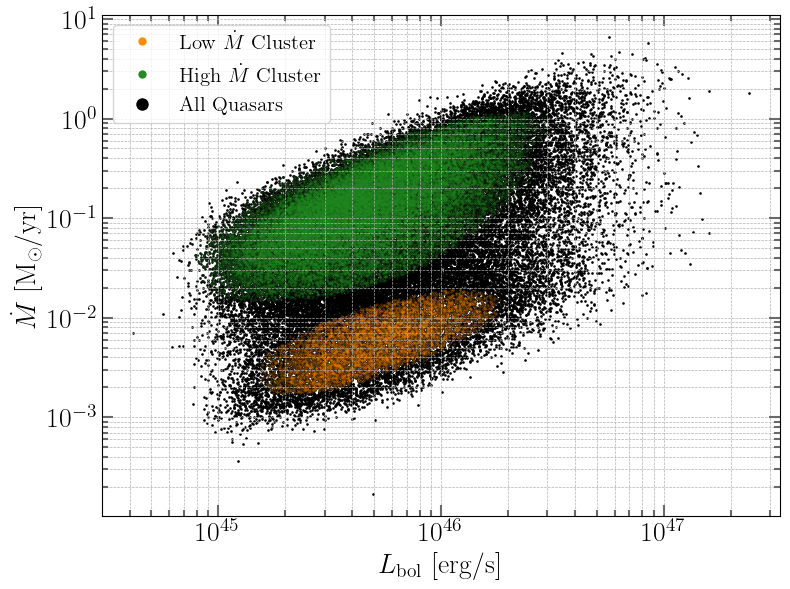

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Full dataset
x_all = results_df['L_bol']
y_all = results_df['Mdot']*cover_factor

# Filter: positive and non-null values only
valid_all = (x_all > 0) & (y_all > 0)
x = x_all[valid_all]
y = y_all[valid_all]


x_subHigh = cluster_0_df['L_bol']
y_subHigh = cluster_0_df['Mdot']*cover_factor

x_subLow = cluster_1_df['L_bol']
y_subLow = cluster_1_df['Mdot']*cover_factor

# # Log-transform
# log_x = np.log10(x)
# log_y = np.log10(y)
# log_x_sub = np.log10(x_sub)
# log_y_sub = np.log10(y_sub)

# # Linear regressions in log-log space
# slope_all, intercept_all, *_ = linregress(log_x, log_y)
# slope_sub, intercept_sub, *_ = linregress(log_x_sub, log_y_sub)

# # Fit lines
# x_fit = np.logspace(np.log10(min(x.min(), x_sub.min())), np.log10(max(x.max(), x_sub.max())), 100)
# y_fit_all = 10**(slope_all * np.log10(x_fit) + intercept_all)
# y_fit_sub = 10**(slope_sub * np.log10(x_fit) + intercept_sub)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='k', s=0.8, alpha=1, label='All Data')
plt.scatter(x_subLow, y_subLow, color='darkorange', s=0.1, alpha=0.5, label=r'Low $\dot{M}$ Cluster')
plt.scatter(x_subHigh, y_subHigh, color='forestgreen', s=0.1, alpha=0.5, label=r'High $\dot{M}$ Cluster')
# plt.plot(x_fit, y_fit_all, color='blue', label=f'Fit All: slope = {slope_all:.2f}')
# plt.plot(x_fit, y_fit_sub, color='orange', label=f'Fit Subset: slope = {slope_sub:.2f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$L_{\mathrm{bol}}$ [erg/s]', fontsize=20)
plt.ylabel('$\dot{M}$ [M$_{\odot}$/yr]', fontsize=20)
# plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
plt.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
plt.minorticks_on()
plt.tight_layout()
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=r'Low $\dot{M}$ Cluster',
           markerfacecolor='darkorange', markersize=7),
    Line2D([0], [0], marker='o', color='w', label=r'High $\dot{M}$ Cluster',
           markerfacecolor='forestgreen', markersize=7),
    Line2D([0], [0], marker='o', color='w', label=r'All Quasars',
           markerfacecolor='k', markersize=10)]
plt.legend(
    handles=legend_elements,
    fontsize=15
)
plt.savefig("Results/Figures/Mdot_LinearRelation.png", bbox_inches="tight", dpi=300)
plt.show()


## Stack both sub clusters

Seperate trough table by cluster

In [23]:
cluster0_trough_table = trough_table.merge(
    cluster_0_df[['Thing ID', 'Fiber ID']],
    left_on=['THING_ID', 'FIBERID'],
    right_on=['Thing ID', 'Fiber ID'],
    how='inner'
)

cluster1_trough_table = trough_table.merge(
    cluster_1_df[['Thing ID', 'Fiber ID']],
    left_on=['THING_ID', 'FIBERID'],
    right_on=['Thing ID', 'Fiber ID'],
    how='inner'
)

In [24]:
print("Cluster 0:", len(cluster0_trough_table))
print("Cluster 1:", len(cluster1_trough_table))
print(f"Total from Clusters: {len(cluster0_trough_table)+len(cluster1_trough_table)}")
print("Trough Table:", len(trough_table))


Cluster 0: 18064
Cluster 1: 1893
Total from Clusters: 19957
Trough Table: 159690


In [25]:
# Create combined keys for cluster IDs
cluster_keys = set(zip(cluster_0_df['Thing ID'], cluster_0_df['Fiber ID'])) | \
               set(zip(cluster_1_df['Thing ID'], cluster_1_df['Fiber ID']))

# Create keys for trough_table
trough_keys = set(zip(trough_table['THING_ID'], trough_table['FIBERID']))

# Find unmatched
unmatched = trough_keys - cluster_keys
print("Unmatched count:", len(unmatched))
unmatched


Unmatched count: 94508


{(371057088.0, 716.0),
 (417286208.0, 649.0),
 (201432464.0, 837.0),
 (147189136.0, 954.0),
 (313138816.0, 724.0),
 (494946208.0, 175.0),
 (148802096.0, 839.0),
 (102573072.0, 614.0),
 (440016512.0, 348.0),
 (479984608.0, 794.0),
 (77964048.0, 701.0),
 (130761784.0, 438.0),
 (48351688.0, 233.0),
 (490045248.0, 480.0),
 (500329824.0, 748.0),
 (259609936.0, 826.0),
 (467959168.0, 808.0),
 (376937376.0, 504.0),
 (297574272.0, 764.0),
 (387897024.0, 671.0),
 (115691472.0, 324.0),
 (506665088.0, 398.0),
 (327484800.0, 204.0),
 (235839104.0, 750.0),
 (320609376.0, 185.0),
 (211636464.0, 338.0),
 (131073312.0, 614.0),
 (285484864.0, 744.0),
 (445080576.0, 572.0),
 (313686400.0, 661.0),
 (378886976.0, 734.0),
 (476990944.0, 26.0),
 (262906768.0, 894.0),
 (453392992.0, 24.0),
 (31971440.0, 186.0),
 (485454784.0, 750.0),
 (282100000.0, 759.0),
 (410102688.0, 584.0),
 (77700600.0, 872.0),
 (456725504.0, 540.0),
 (495383552.0, 462.0),
 (208371472.0, 122.0),
 (495133856.0, 207.0),
 (223692048.0, 35

Calculate trough statistics and append stacking spectra for each clusters trough table

In [26]:
cluster0_trough_stats, cluster0_stacking_spectra = LineLocking.get_real_spectra_stats(cluster0_trough_table, specdir, Continuum_Type='PCA', balfilename=balfilename, pcaeigenfile=pcaeigenfile, meanContinuum=meancontinuum)
print(f"Rejected {cluster0_trough_stats["Rejection Counter"][0]} troughs. {cluster0_trough_table.shape[0]-cluster0_trough_stats["Rejection Counter"][0]} remaining.")
print("Finished Calculating Distributions!")

cluster1_trough_stats, cluster1_stacking_spectra = LineLocking.get_real_spectra_stats(cluster1_trough_table, specdir, Continuum_Type='PCA', balfilename=balfilename, pcaeigenfile=pcaeigenfile, meanContinuum=meancontinuum)
print(f"Rejected {cluster1_trough_stats["Rejection Counter"][0]} troughs. {cluster1_trough_table.shape[0]-cluster1_trough_stats["Rejection Counter"][0]} remaining.")
print("Finished Calculating Distributions!")

  0%|          | 0/18064 [00:00<?, ?it/s]

Rejected 12750 troughs. 5314 remaining.
Finished Calculating Distributions!


  0%|          | 0/1893 [00:00<?, ?it/s]

Rejected 1767 troughs. 126 remaining.
Finished Calculating Distributions!


Create KDEs for each cluster

In [27]:
from scipy.stats import gaussian_kde

cluster0_values = np.vstack([cluster0_trough_stats['Blue Depths'], cluster0_trough_stats['Red Depths'], cluster0_trough_stats['Noises'], cluster0_trough_stats['Trough Depths'], cluster0_trough_stats['Trough Widths'], cluster0_trough_stats['Triplet Depths']])
cluster0_master_KDE = gaussian_kde(cluster0_values, bw_method=1/8)

cluster1_values = np.vstack([cluster1_trough_stats['Blue Depths'], cluster1_trough_stats['Red Depths'], cluster1_trough_stats['Noises'], cluster1_trough_stats['Trough Depths'], cluster1_trough_stats['Trough Widths'], cluster1_trough_stats['Triplet Depths']])
cluster1_master_KDE = gaussian_kde(cluster1_values, bw_method=1/8)

Use the KDEs to generate mock trough tables for each cluster

In [28]:
# Set up a pandas dataframe to act as a table to hold all of the mock spectra
cluster0_Mock_Trough_Table = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])

# Create and store thousands of mock spectra 
print(f'Creating a Sample of {len(cluster0_trough_table)} Mock Spectra...')
for k in tqdm(range(len(cluster0_trough_table))):
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1548.2-60*0.3, 1548.2+60*0.3), KDE=cluster0_master_KDE, return_params=True, triplet=False)
    cluster0_Mock_Trough_Table.loc[ len(cluster0_Mock_Trough_Table) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]

# Perform the statistics
print(f'Building up Mock Statistics...')
cluster0_mock_stats, cluster0_mock_stacking_spectra = LineLocking.get_mock_spectra_stats(cluster0_Mock_Trough_Table)
print(f'Finished! {cluster0_mock_stats['Rejection Counter'][0]} troughs rejected.')


# Set up a pandas dataframe to act as a table to hold all of the mock spectra
cluster1_Mock_Trough_Table = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])

# Create and store thousands of mock spectra 
print(f'Creating a Sample of {len(cluster1_trough_table)} Mock Spectra...')
for k in tqdm(range(len(cluster1_trough_table))):
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1548.2-60*0.3, 1548.2+60*0.3), KDE=cluster1_master_KDE, return_params=True, triplet=False)
    cluster1_Mock_Trough_Table.loc[ len(cluster1_Mock_Trough_Table) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]

# Perform the statistics
print(f'Building up Mock Statistics...')
cluster1_mock_stats, cluster1_mock_stacking_spectra = LineLocking.get_mock_spectra_stats(cluster1_Mock_Trough_Table)
print(f'Finished! {cluster1_mock_stats['Rejection Counter'][0]} troughs rejected.')



Creating a Sample of 18064 Mock Spectra...


  0%|          | 0/18064 [00:00<?, ?it/s]

Building up Mock Statistics...


  0%|          | 0/18064 [00:00<?, ?it/s]

Finished! 0 troughs rejected.
Creating a Sample of 1893 Mock Spectra...


  0%|          | 0/1893 [00:00<?, ?it/s]

Building up Mock Statistics...


  0%|          | 0/1893 [00:00<?, ?it/s]

Finished! 0 troughs rejected.


Now Stack an compare

In [29]:
def nanweighted_mean_std(data, weights, axis=0):
    data = np.asarray(data)
    weights = np.asarray(weights)

    # Expand weights to match data dimensions along the averaging axis
    if axis == 0 and weights.ndim == 1:
        weights = weights[:, np.newaxis]
    elif axis == 1 and weights.ndim == 1:
        weights = weights[np.newaxis, :]

    # Mask NaNs
    mask = ~np.isnan(data)
    safe_data = np.where(mask, data, 0)
    safe_weights = np.where(mask, weights, 0)

    # Compute weighted mean
    weighted_sum = np.sum(safe_data * safe_weights, axis=axis)
    sum_weights = np.sum(safe_weights, axis=axis)
    with np.errstate(divide='ignore', invalid='ignore'):
        mean = np.divide(weighted_sum, sum_weights)
        mean[sum_weights == 0] = np.nan

    # Expand mean back to data shape for broadcasting
    mean_broadcast = np.expand_dims(mean, axis=axis)
    squared_diff = (safe_data - mean_broadcast) ** 2

    # Compute weighted standard deviation
    weighted_squared_diff = squared_diff * safe_weights
    variance = np.sum(weighted_squared_diff, axis=axis) / sum_weights
    std = np.sqrt(variance)
    std[sum_weights == 0] = np.nan

    return mean, std


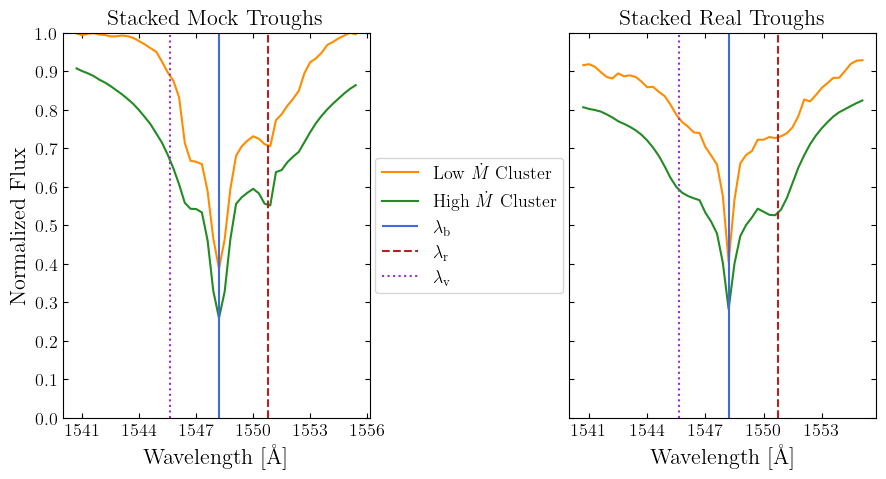

In [30]:
#### Stack the Mock Spectra
cluster0_stacked_mocks, _ = nanweighted_mean_std(np.vstack(cluster0_mock_stacking_spectra), cluster0_mock_stats["Weights"], axis=0)
cluster1_stacked_mocks, _ = nanweighted_mean_std(np.vstack(cluster1_mock_stacking_spectra), cluster1_mock_stats["Weights"], axis=0)
stacking_wavelengths_mocks = np.arange(1548.2-25*0.3, 1548.2+25*0.3, 0.3)

#### Stack the Real Spectra
cluster0_weighted, _ = nanweighted_mean_std(np.vstack(cluster0_stacking_spectra), cluster0_trough_stats["Weights"], axis=0)
cluster1_weighted, _ = nanweighted_mean_std(np.vstack(cluster1_stacking_spectra), cluster1_trough_stats["Weights"], axis=0)

stacking_wavelengths = np.arange(900.2, 1599.8, 0.3)
CIV_wlMin = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[0]))
CIV_wlMax = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[-1]))


# Plot the Stacks
labelsize=16
ticksize = 13
fig, axes = plt.subplots(1,2, figsize=(10.5, 5), sharey=True)
axes[0].plot(stacking_wavelengths_mocks, cluster1_stacked_mocks, c='darkorange')
axes[0].plot(stacking_wavelengths_mocks, cluster0_stacked_mocks, c='forestgreen')
axes[0].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[0].set_ylabel('Normalized Flux', fontsize=labelsize)
axes[0].set_title('Stacked Mock Troughs', fontsize=labelsize)
axes[0].set_ylim(0.0, 1)
axes[0].set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
axes[0].set_xticks([1541,1544,1547,1550,1553,1556])
axes[0].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-')
axes[0].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--')
axes[0].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':')
axes[0].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)

axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], cluster1_weighted[CIV_wlMin:CIV_wlMax], c='darkorange', label=r'Low $\dot{M}$ Cluster')
axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], cluster0_weighted[CIV_wlMin:CIV_wlMax], c='forestgreen', label=r'High $\dot{M}$ Cluster')
axes[1].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[1].set_title('Stacked Real Troughs', fontsize=labelsize)
axes[1].set_ylim(0.0, 1)
axes[1].set_xticks([1541,1544,1547,1550,1553,1556])
axes[1].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$')
axes[1].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
axes[1].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$')
axes[1].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
axes[1].legend(fontsize=ticksize, loc='lower right', bbox_to_anchor=(0.01, 0.3))

plt.subplots_adjust(wspace=0.65)
plt.savefig("./Results/Figures/SubCluster_Stack.png", bbox_inches="tight", dpi=300)
plt.show()




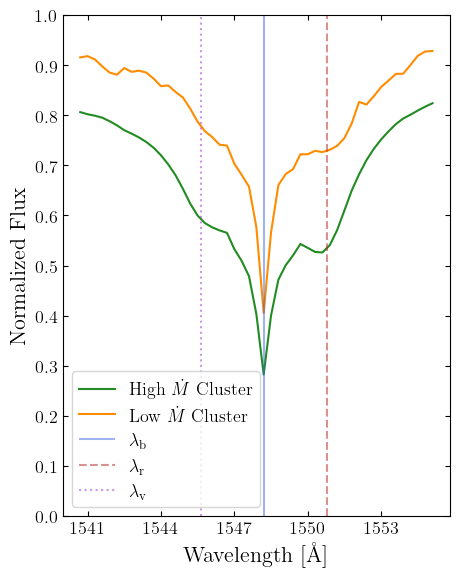

In [31]:
labelsize=16
ticksize = 13
fig, ax = plt.subplots(1,1, figsize=(5, 6.5), sharey=True)
ax.plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], cluster0_weighted[CIV_wlMin:CIV_wlMax], c='forestgreen', label=r'High $\dot{M}$ Cluster')
ax.plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], cluster1_weighted[CIV_wlMin:CIV_wlMax], c='darkorange', label=r'Low $\dot{M}$ Cluster')
ax.set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
ax.set_ylabel('Normalized Flux', fontsize=labelsize)
ax.set_ylim(0.0, 1)
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
ax.set_xticks([1541,1544,1547,1550,1553,1556])
ax.vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$', alpha=0.5)
ax.vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$', alpha=0.5)
ax.vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$', alpha=0.5)
ax.tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
plt.legend(fontsize=ticksize)
plt.savefig("./Results/Figures/SubCluster_Stack.png", bbox_inches="tight", dpi=300)
plt.show()

In [32]:
from scipy.optimize import fsolve

xc = 0.005
Delta = 0.5



def beta(lam):
    global Delta
    return np.exp(-(lam-1548.20)**2/(2*Delta**2))
def alpha(lam):
    global Delta
    return np.exp(-(lam-1550.77)**2/(2*Delta**2))
def gamma(lam):
    global Delta
    return np.exp(-(lam-1545.63)**2/(2*Delta**2))


# Define the system of equations
def C0_system_of_equations(vars):
    x, B, R = vars
    global C
    # Wavelengths of the blue line, red line, and violet line respectively
    lb = 1548.20
    lr = 1550.77
    lv = 1545.63
    # Measured values from the real stack of the blue line, red line, and violet line respectively 
    measured_b = np.interp(1548.20, stacking_wavelengths, cluster0_weighted)
    measured_r = np.interp(1550.77, stacking_wavelengths, cluster0_weighted)
    measured_v = np.interp(1545.63, stacking_wavelengths, cluster0_weighted)
    # 3 equations that comprise the system of equations
    eq1 = x*C*B**(beta(lb))*R**(alpha(lb))*B**(gamma(lb))*R**(beta(lb))-(x+xc-1)*C*B**(beta(lb))*R**(alpha(lb))+xc*C*B**(gamma(lb))*R**(beta(lb))+1-C-measured_b
    eq2 = x*C*B**(beta(lr))*R**(alpha(lr))*B**(gamma(lr))*R**(beta(lr))-(x+xc-1)*C*B**(beta(lr))*R**(alpha(lr))+xc*C*B**(gamma(lr))*R**(beta(lr))+1-C-measured_r
    eq3 = x*C*B**(beta(lv))*R**(alpha(lv))*B**(gamma(lv))*R**(beta(lv))-(x+xc-1)*C*B**(beta(lv))*R**(alpha(lv))+xc*C*B**(gamma(lv))*R**(beta(lv))+1-C-measured_v
    return [eq1, eq2, eq3]

# Define the system of equations
def C1_system_of_equations(vars):
    x, B, R = vars
    global C
    # Wavelengths of the blue line, red line, and violet line respectively
    lb = 1548.20
    lr = 1550.77
    lv = 1545.63
    # Measured values from the real stack of the blue line, red line, and violet line respectively 
    measured_b = np.interp(1548.20, stacking_wavelengths, cluster1_weighted)
    measured_r = np.interp(1550.77, stacking_wavelengths, cluster1_weighted)
    measured_v = np.interp(1545.63, stacking_wavelengths, cluster1_weighted)
    # 3 equations that comprise the system of equations
    eq1 = x*C*B**(beta(lb))*R**(alpha(lb))*B**(gamma(lb))*R**(beta(lb))-(x+xc-1)*C*B**(beta(lb))*R**(alpha(lb))+xc*C*B**(gamma(lb))*R**(beta(lb))+1-C-measured_b
    eq2 = x*C*B**(beta(lr))*R**(alpha(lr))*B**(gamma(lr))*R**(beta(lr))-(x+xc-1)*C*B**(beta(lr))*R**(alpha(lr))+xc*C*B**(gamma(lr))*R**(beta(lr))+1-C-measured_r
    eq3 = x*C*B**(beta(lv))*R**(alpha(lv))*B**(gamma(lv))*R**(beta(lv))-(x+xc-1)*C*B**(beta(lv))*R**(alpha(lv))+xc*C*B**(gamma(lv))*R**(beta(lv))+1-C-measured_v
    return [eq1, eq2, eq3]

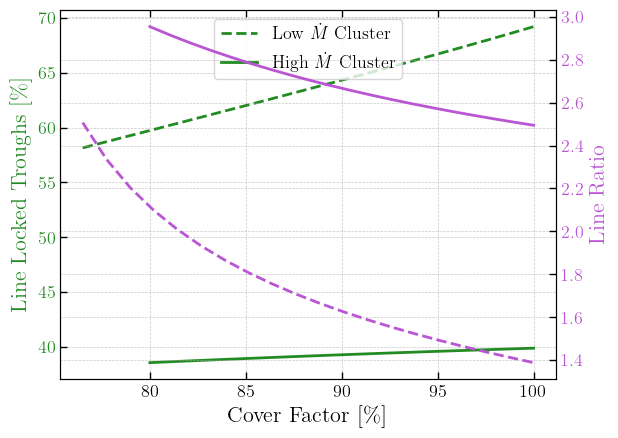

In [33]:
C0_cover_factors = np.linspace(0.765, 1.00, 20)  # Cover fraction
C0_initial_fraction_guesses = np.linspace(0.55, 0.7, 20)
C0_initial_B_guesses = np.linspace(0.2, 0.46, 20)
C0_initial_R_guesses = np.linspace(0.48, 0.58, 20)

C0_fractions1 = []
C0_line_ratios1 = []
C0_tau_red_1 = []
C0_tau_blue_1 = []
C0_fractions2 = []
C0_line_ratios2 = []
C0_tau_red_2 = []
C0_tau_blue_2 = []
C0_fractions3 = []
C0_line_ratios3 = []
C0_tau_red_3 = []
C0_tau_blue_3 = []
for i, C0_cover_factor in enumerate(C0_cover_factors):
    C = C0_cover_factor
    # Solve the system of equations for lower bound of contamination fraction
    xc = 0.00
    initial_guess = [C0_initial_fraction_guesses[i], C0_initial_B_guesses[i], C0_initial_R_guesses[i]]
    solution = fsolve(C0_system_of_equations, initial_guess)
    C0_fractions1.append(solution[0])
    C0_line_ratios1.append(-np.log(solution[1])/(-np.log(solution[2])))
    C0_tau_red_1.append(-np.log(solution[2]))
    C0_tau_blue_1.append(-np.log(solution[1]))
     # Solve the system of equations for the most probable contamination fraction
    xc=0.005
    solution = fsolve(C0_system_of_equations, initial_guess)
    C0_fractions2.append(solution[0])
    C0_line_ratios2.append(-np.log(solution[1])/(-np.log(solution[2])))
    C0_tau_red_2.append(-np.log(solution[2]))
    C0_tau_blue_2.append(-np.log(solution[1]))
     # Solve the system of equations for upper bound of contamination fraction
    xc = 0.01
    solution = fsolve(C0_system_of_equations, initial_guess)
    C0_fractions3.append(solution[0])
    C0_line_ratios3.append(-np.log(solution[1])/(-np.log(solution[2])))
    C0_tau_red_3.append(-np.log(solution[2]))
    C0_tau_blue_3.append(-np.log(solution[1]))


C1_cover_factors = np.linspace(0.80, 1.00, 20)  # Cover fraction
C1_initial_fraction_guesses = np.linspace(0.55, 0.7, 20)
C1_initial_B_guesses = np.linspace(0.2, 0.46, 20)
C1_initial_R_guesses = np.linspace(0.48, 0.58, 20)

C1_fractions1 = []
C1_line_ratios1 = []
C1_tau_red_1 = []
C1_tau_blue_1 = []
C1_fractions2 = []
C1_line_ratios2 = []
C1_tau_red_2 = []
C1_tau_blue_2 = []
C1_fractions3 = []
C1_line_ratios3 = []
C1_tau_red_3 = []
C1_tau_blue_3 = []
for i, C1_cover_factor in enumerate(C1_cover_factors):
    C = C1_cover_factor
    # Solve the system of equations for lower bound of contamination fraction
    xc = 0.00
    initial_guess = [C1_initial_fraction_guesses[i], C1_initial_B_guesses[i], C1_initial_R_guesses[i]]
    solution = fsolve(C1_system_of_equations, initial_guess)
    C1_fractions1.append(solution[0])
    C1_line_ratios1.append(-np.log(solution[1])/(-np.log(solution[2])))
    C1_tau_red_1.append(-np.log(solution[2]))
    C1_tau_blue_1.append(-np.log(solution[1]))
     # Solve the system of equations for the most probable contamination fraction
    xc=0.005
    solution = fsolve(C1_system_of_equations, initial_guess)
    C1_fractions2.append(solution[0])
    C1_line_ratios2.append(-np.log(solution[1])/(-np.log(solution[2])))
    C1_tau_red_2.append(-np.log(solution[2]))
    C1_tau_blue_2.append(-np.log(solution[1]))
     # Solve the system of equations for upper bound of contamination fraction
    xc = 0.01
    solution = fsolve(C1_system_of_equations, initial_guess)
    C1_fractions3.append(solution[0])
    C1_line_ratios3.append(-np.log(solution[1])/(-np.log(solution[2])))
    C1_tau_red_3.append(-np.log(solution[2]))
    C1_tau_blue_3.append(-np.log(solution[1]))


fig, ax1 = plt.subplots()
# Left Y-axis
ax1.plot(C0_cover_factors * 100, [x * 100 for x in C0_fractions2], label=r'Low $\dot{M}$ Cluster', color='forestgreen', lw=2, linestyle='--')
ax1.plot(C1_cover_factors * 100, [x * 100 for x in C1_fractions2], label=r'High $\dot{M}$ Cluster', color='forestgreen', lw=2)
ax1.set_xlabel(r'Cover Factor [\%]', fontsize=labelsize)
ax1.set_ylabel(r'Line Locked Troughs [\%]', color='forestgreen', fontsize=labelsize)
# General tick settings for ax1
ax1.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize, labelcolor='forestgreen')
# Explicitly set bottom x-axis ticks to black
ax1.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# Right Y-axis
ax2 = ax1.twinx()
ax2.plot(C0_cover_factors * 100, C0_line_ratios2, color='mediumorchid', lw=2, linestyle='--')
ax2.plot(C1_cover_factors * 100, C1_line_ratios2, color='mediumorchid', lw=2)
ax2.set_ylabel('Line Ratio', color='mediumorchid', fontsize=labelsize)
ax2.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize, labelcolor='mediumorchid')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

ax1.legend(fontsize=labelsize-3, loc='upper center')
plt.savefig("./Results/Figures/Line_Locking_Fraction.png", bbox_inches="tight", dpi=300)
plt.show()


# plt.fill_between(cover_factors * 100, tau_blue_1, tau_blue_3, color='royalblue', alpha=0.3)
# plt.plot(cover_factors * 100, tau_blue_2, color='royalblue', label=r'$\tau_b$', lw=2)
# plt.fill_between(cover_factors * 100, tau_red_1, tau_red_3, color='firebrick', alpha=0.3)
# plt.plot(cover_factors * 100, tau_red_2, color='firebrick', label=r'$\tau_b$', lw=2)
# plt.xlabel(r'Cover Factor [\%]', fontsize=labelsize)
# plt.ylabel(r'Optical Depth', fontsize=labelsize)
# # General tick settings for ax1
# plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
#                 labelsize=ticksize)
# # Explicitly set bottom x-axis ticks to black
# plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
#                 labelsize=ticksize, labelcolor='black', color='black')
# plt.tight_layout()
# plt.show()